# Feature Engineering & Return Analysis

## Objectives
1. **Return transformations**: Understand log vs arithmetic returns and their properties
2. **Volatility normalization**: Learn why and how to normalize by volatility
3. **Feature generation**: Build 12 candidate features across 4 families
4. **Statistical properties**: Test stationarity and visualize distributions

## Key Concepts

**Log Returns (Additivity Property)**:
- $r_{t} = \ln(P_t / P_{t-1})$
- Multi-period: $r_{t \to t+n} = r_t + r_{t+1} + ... + r_{t+n-1}$
- Closer to normal distribution than arithmetic returns

**Z-Score Interpretation**:
- $z = (x - \mu) / \sigma$
- $|z| < 1$: Within 1σ (68% of data)
- $|z| < 2$: Within 2σ (95% of data)
- $|z| > 3$: Extreme outlier (0.3% of data)

**Why Volatility Normalization?**
- Makes signals regime-invariant
- In high-vol periods, same absolute move has lower z-score
- Prevents false signals during market stress

In [1]:
# Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import project modules
from src.data.forensics import load_csv_data
from src.features import (
    FeatureLibrary,
    compute_log_returns,
    compute_rolling_vol,
    compute_zscore,
)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Load Data

Load USDJPY H1 (60-minute) data from raw CSV.

In [2]:
# Load USDJPY H1 data
df = load_csv_data(Path.cwd().parent / 'data/raw/USDJPY_10yr_1h_dukascopy.csv')

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Data shape: (62303, 5)
Date range: 2016-03-13 21:00:00+00:00 to 2026-03-10 20:00:00+00:00

Columns: ['open', 'high', 'low', 'close', 'volume']

First 5 rows:


,open,high,low,close,volume
datetime,,,,,
2016-03-13 21:00:00+00:00,113.925,113.958,113.886,113.916,595.44
2016-03-13 22:00:00+00:00,113.916,113.916,113.666,113.697,4620.17
2016-03-13 23:00:00+00:00,113.695,113.793,113.640,113.775,2904.76
2016-03-14 00:00:00+00:00,113.772,113.937,113.716,113.930,7629.47
2016-03-14 01:00:00+00:00,113.929,114.007,113.869,113.935,6990.16


## 2. Theory: Log Returns vs Arithmetic Returns

**Arithmetic Returns**:
$$r_t^{arith} = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

**Log Returns**:
$$r_t^{log} = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

**Key Property — Additivity**:
$$r_{1 \to 3}^{log} = r_1^{log} + r_2^{log} + r_3^{log}$$

This makes log returns ideal for:
- Multi-period aggregation
- Statistical modeling (closer to normal distribution)
- Avoiding compounding errors

**Portfolio Property**:
- Arithmetic returns: $r_p = w_1 r_1 + w_2 r_2$ (portfolio additivity)
- Log returns: $r_p^{total} = \sum r_i$ (time additivity)

For small returns, they are approximately equal: $r^{log} \approx r^{arith}$

In [3]:
# Compute log returns
log_returns = compute_log_returns(df['close'])

print(f"Log returns computed: {len(log_returns)} periods")
print(f"Non-null values: {log_returns.notna().sum()}")
print(f"Mean: {log_returns.mean():.6f}")
print(f"Std: {log_returns.std():.6f}")
print(f"\nFirst 10 non-null values:")
log_returns.dropna().head(10)

Log returns computed: 62303 periods
Non-null values: 62302
Mean: 0.000005
Std: 0.001154

First 10 non-null values:


datetime
2016-03-13 22:00:00+00:00   -0.001924
2016-03-13 23:00:00+00:00    0.000686
2016-03-14 00:00:00+00:00    0.001361
2016-03-14 01:00:00+00:00    0.000044
2016-03-14 02:00:00+00:00   -0.000281
2016-03-14 03:00:00+00:00   -0.000544
2016-03-14 04:00:00+00:00   -0.000756
2016-03-14 05:00:00+00:00    0.000422
2016-03-14 06:00:00+00:00    0.000439
2016-03-14 07:00:00+00:00   -0.000738
Name: close, dtype: float64

## 3. Theory: Volatility Normalization & Z-Scores

**Why Normalize by Volatility?**

Raw returns are non-comparable across regimes:
- A 0.5% move in low-vol regime → significant
- A 0.5% move in high-vol regime → noise

**Z-Score Formula**:
$$z_t = \frac{x_t - \mu_t}{\sigma_t}$$

where $\mu_t$ and $\sigma_t$ are computed over a rolling window.

**Interpretation**:
- $|z| < 1$: Within 1 standard deviation (68% of data under normal distribution)
- $1 < |z| < 2$: Within 2 standard deviations (95% of data)
- $|z| > 2$: Within 3 standard deviations (99.7% of data)
- $|z| > 3$: Extreme outlier (0.3% of data)

**Key Benefit**: Z-scores make signals regime-invariant. A z-score of 2 means "2 standard deviations above normal" regardless of whether the market is calm or volatile.

## 4. Generate 12 Candidate Features

We'll create features across **4 families**:

### Momentum Features
- `mom_5`: 5-period momentum (log return over 5 bars)
- `mom_10`: 10-period momentum
- `mom_20`: 20-period momentum

### Volatility Features
- `vol_10`: 10-period rolling volatility
- `vol_20`: 20-period rolling volatility
- `vol_50`: 50-period rolling volatility

### Mean-Reversion Features
- `zscore_20`: 20-period z-score of returns
- `zscore_50`: 50-period z-score of returns
- `distance_from_ma_20`: Z-scored distance from 20-period moving average

### Microstructure Features
- `range`: Bar range (high - low)
- `true_range`: True range accounting for gaps
- `close_position`: Where close occurred within bar range [0,1]

In [4]:
# Initialize feature library
lib = FeatureLibrary()

# Create feature DataFrame
features = pd.DataFrame(index=df.index)

# Momentum features (3)
features['mom_5'] = lib.momentum(df['close'], period=5)
features['mom_10'] = lib.momentum(df['close'], period=10)
features['mom_20'] = lib.momentum(df['close'], period=20)

# Volatility features (3)
features['vol_10'] = lib.volatility(log_returns, window=10)
features['vol_20'] = lib.volatility(log_returns, window=20)
features['vol_50'] = lib.volatility(log_returns, window=50)

# Mean-reversion features (3)
features['zscore_20'] = compute_zscore(log_returns, window=20)
features['zscore_50'] = compute_zscore(log_returns, window=50)
features['distance_from_ma_20'] = lib.distance_from_ma(df['close'], window=20)

# Microstructure features (3)
features['range'] = lib.range_feature(df['high'], df['low'])
features['true_range'] = lib.true_range(df['high'], df['low'], df['close'])
features['close_position'] = lib.close_position(df['high'], df['low'], df['close'])

print(f"Features generated: {features.shape}")
print(f"\nSummary statistics:")
features.describe()

Features generated: (62303, 12)

Summary statistics:


,mom_5,mom_10,mom_20,vol_10,vol_20,vol_50,zscore_20,zscore_50,distance_from_ma_20,range,true_range,close_position
count,62298.000000,62293.000000,62283.000000,62293.000000,62283.000000,62253.000000,62283.000000,62253.000000,62265.000000,62303.000000,62303.00000,62297.000000
mean,0.000026,0.000052,0.000105,0.000944,0.000982,0.001017,-0.006332,-0.004494,0.112438,0.184406,0.18505,0.517806
std,0.002600,0.003682,0.005227,0.000662,0.000605,0.000545,0.983783,0.995874,1.587497,0.165345,0.16633,0.293837
min,-0.050768,-0.049088,-0.044332,0.000041,0.000113,0.000182,-4.235278,-6.803662,-9.726671,0.000000,0.00000,0.000000
25%,-0.001049,-0.001588,-0.002384,0.000549,0.000614,0.000666,-0.567690,-0.522907,-0.942557,0.090000,0.09000,0.261146
50%,0.000081,0.000138,0.000261,0.000789,0.000843,0.000895,0.000482,0.002409,0.125498,0.142000,0.14200,0.527273
75%,0.001205,0.001823,0.002817,0.001151,0.001181,0.001213,0.570247,0.532601,1.163231,0.227000,0.22800,0.780488
max,0.023520,0.032711,0.042268,0.011705,0.008556,0.005768,4.153513,6.324825,8.942695,5.895000,5.89500,1.000000


## 5. Distribution Analysis

**Why This Matters**:
- FX features often exhibit **heavy tails** (fat-tailed distributions)
- **Regime shifts** can cause multiple modes in the distribution
- **Skewness** indicates directional bias
- These properties affect risk modeling and strategy design

We'll visually inspect each feature's distribution to detect:
1. Normality (or lack thereof)
2. Outliers and extreme values
3. Multi-modal patterns (regime changes)

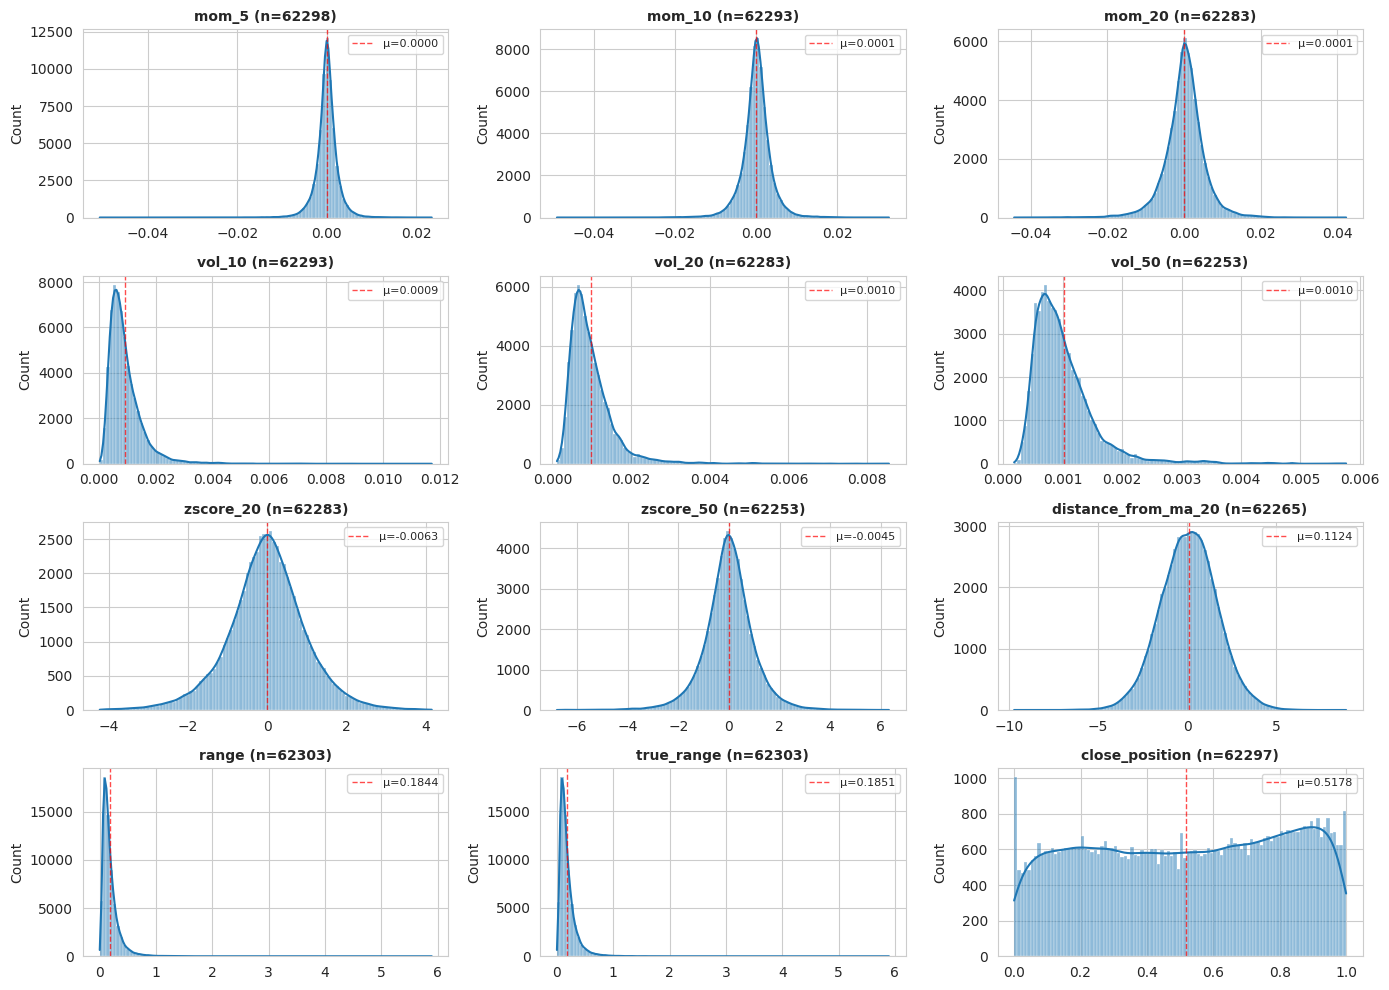

✓ Distribution plots generated


In [5]:
# Plot distributions for all 12 features
fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(features.columns):
    data = features[col].dropna()
    
    sns.histplot(data, bins=100, ax=axes[idx], kde=True)
    axes[idx].set_title(f'{col} (n={len(data)})', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('')
    
    # Add mean and std to plot
    mean_val = data.mean()
    std_val = data.std()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'μ={mean_val:.4f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Distribution plots generated")

## 6. Stationarity Testing

**Augmented Dickey-Fuller (ADF) Test**:
- **Null hypothesis**: Series has a unit root (non-stationary)
- **Alternative hypothesis**: Series is stationary

**Interpretation**:
- $p < 0.05$: Reject null → **stationary**
- $p > 0.05$: Fail to reject null → **non-stationary**

**Why This Matters**:
- Most price-based features are non-stationary (random walk)
- Returns and z-scores tend to be stationary (mean-reverting)
- Non-stationarity ≠ unusable (many profitable features are non-stationary)
- The test mainly detects price-like behavior vs return-like behavior

In [6]:
# Run ADF test on each feature
def run_adf_test(series):
    """Run ADF test and return results."""
    clean_series = series.dropna()
    if len(clean_series) < 10:
        return {'ADF_Statistic': np.nan, 'P_Value': np.nan}
    
    result = adfuller(clean_series, autolag='AIC')
    return {
        'ADF_Statistic': result[0],
        'P_Value': result[1]
    }

# Test all features
stationarity_results = []

for col in features.columns:
    result = run_adf_test(features[col])
    stationarity_results.append({
        'Feature': col,
        'ADF_Statistic': result['ADF_Statistic'],
        'P_Value': result['P_Value'],
        'Is_Stationary': result['P_Value'] < 0.05 if not np.isnan(result['P_Value']) else False
    })

# Create results DataFrame
results_df = pd.DataFrame(stationarity_results)
results_df = results_df.sort_values('P_Value')

print("Stationarity Test Results (Augmented Dickey-Fuller)")
print("=" * 70)
results_df

Stationarity Test Results (Augmented Dickey-Fuller)


,Feature,ADF_Statistic,P_Value,Is_Stationary
0,mom_5,-30.243126,0.000000e+00,True
1,mom_10,-28.350984,0.000000e+00,True
2,mom_20,-25.379320,0.000000e+00,True
7,zscore_50,-44.959203,0.000000e+00,True
6,zscore_20,-47.332283,0.000000e+00,True
8,distance_from_ma_20,-38.699859,0.000000e+00,True
11,close_position,-31.345575,0.000000e+00,True
3,vol_10,-17.446785,4.676555e-30,True
4,vol_20,-14.823292,1.948793e-27,True
10,true_range,-13.524726,2.692332e-25,True


## 7. Key Findings & Conclusions

### Expected Results

**Stationary Features** (p < 0.05):
- Z-score features (`zscore_20`, `zscore_50`) — by construction
- Momentum features may show stationarity (returns-based)
- `close_position` — bounded [0,1], often mean-reverting

**Non-Stationary Features** (p > 0.05):
- `distance_from_ma_20` — follows price trends
- Volatility features — exhibit clustering and regime shifts
- Range features — scale with price levels

### Important Conceptual Note

**Stationarity ≠ Usefulness**

- Many profitable features are non-stationary but mean-reverting after normalization
- The ADF test mainly detects **price-like behavior** vs **return-like behavior**
- Non-stationary features can still be predictive when properly normalized

### Next Steps

1. **Feature selection**: Select subset based on correlation and predictive power
2. **Regime detection**: Identify volatility regimes for adaptive parameters
3. **Signal generation**: Combine features into trading signals
4. **Backtesting**: Test feature-based strategies on hold-out data